In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("twitter sentiment analysis.csv")

# Basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (691248, 2)

Column Names:
['Text', 'Label']

First 5 Rows:


,Text,Label
0,rwanda is set to host the headquarters of unit...,positive
1,it sucks for me since im focused on the nature...,negative
2,shawntarloff itsmieu you can also relate this ...,neutral
3,social security constant political crises dist...,negative
4,filmthepolicela a broken rib can puncture a lu...,negative


In [2]:
# STEP 2: DATA QUALITY CHECK

print("===== DATA QUALITY REPORT =====")

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nLabel Distribution:")
print(df["Label"].value_counts())

print("\nData Types:")
print(df.dtypes)

===== DATA QUALITY REPORT =====

Dataset Shape:
(691248, 2)

Missing Values:
Text     4
Label    0
dtype: int64

Duplicate Rows:
19011

Label Distribution:
Label
positive    248516
negative    244146
neutral     198586
Name: count, dtype: int64

Data Types:
Text     str
Label    str
dtype: object


In [3]:
# STEP 3: TEXT DATA CLEANING

import re

# Remove missing values
df = df.dropna(subset=["Text", "Label"]).copy()

# Remove duplicate tweets
df = df.drop_duplicates(subset=["Text"]).copy()

# Convert text to lowercase
df["Clean_Text"] = df["Text"].astype(str).str.lower()

# Remove URLs
df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x)
)

# Remove mentions and hashtags symbols
df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: re.sub(r"@\w+|#\w+", "", x)
)

# Remove special characters
df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

# Remove extra spaces
df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

print("Cleaned Dataset Shape:", df.shape)

display(df[["Text", "Clean_Text", "Label"]].head())

Cleaned Dataset Shape: (670422, 3)


,Text,Clean_Text,Label
0,rwanda is set to host the headquarters of unit...,rwanda is set to host the headquarters of unit...,positive
1,it sucks for me since im focused on the nature...,it sucks for me since im focused on the nature...,negative
2,shawntarloff itsmieu you can also relate this ...,shawntarloff itsmieu you can also relate this ...,neutral
3,social security constant political crises dist...,social security constant political crises dist...,negative
4,filmthepolicela a broken rib can puncture a lu...,filmthepolicela a broken rib can puncture a lu...,negative


In [5]:
!pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.4 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ -----


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# STEP 5: VADER SENTIMENT ANALYSIS

import nltk
nltk.download("vader_lexicon")

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Calculate sentiment score
df["VADER_Score"] = df["Clean_Text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

# Convert score into sentiment
def get_vader_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["VADER_Sentiment"] = df["VADER_Score"].apply(get_vader_sentiment)

display(df[["Clean_Text", "Label", "VADER_Score", "VADER_Sentiment"]].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ps608\AppData\Roaming\nltk_data...


,Clean_Text,Label,VADER_Score,VADER_Sentiment
0,rwanda is set to host the headquarters of unit...,positive,0.6597,positive
1,it sucks for me since im focused on the nature...,negative,0.5574,positive
2,shawntarloff itsmieu you can also relate this ...,neutral,0.5574,positive
3,social security constant political crises dist...,negative,-0.1396,negative
4,filmthepolicela a broken rib can puncture a lu...,negative,-0.6369,negative


In [7]:
# STEP 6: VADER VS ORIGINAL LABEL

comparison = pd.crosstab(
    df["Label"],
    df["VADER_Sentiment"]
)

print("===== VADER VS ORIGINAL LABEL =====")
display(comparison)

agreement = (
    df["Label"].str.lower() == df["VADER_Sentiment"]
).mean() * 100

print(f"\nVADER Agreement: {agreement:.2f}%")

===== VADER VS ORIGINAL LABEL =====


VADER_Sentiment,negative,neutral,positive
Label,,,
negative,154185,17207,67471
neutral,64496,40262,88793
positive,25632,12411,199965



VADER Agreement: 58.83%


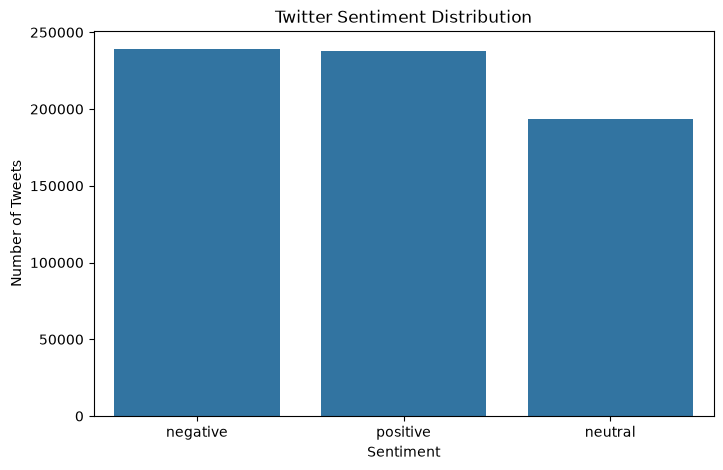

In [8]:
# STEP 7: SENTIMENT DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Label",
    order=df["Label"].value_counts().index
)

plt.title("Twitter Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.show()

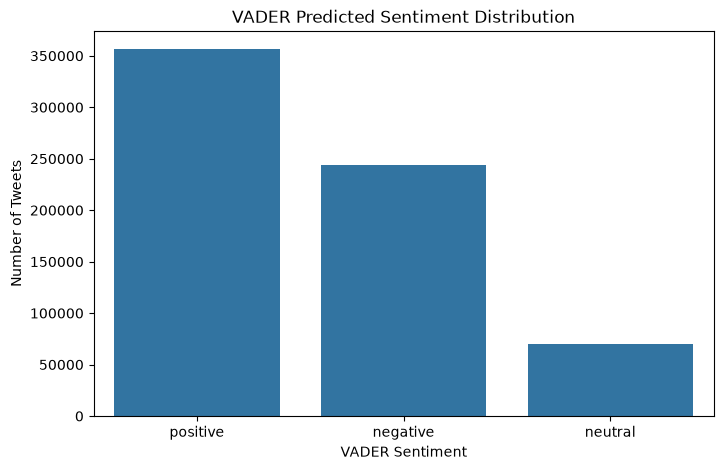

In [9]:
# STEP 8: VADER SENTIMENT DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="VADER_Sentiment",
    order=df["VADER_Sentiment"].value_counts().index
)

plt.title("VADER Predicted Sentiment Distribution")
plt.xlabel("VADER Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [10]:
# STEP 9: MOST COMMON WORDS

from collections import Counter

words = " ".join(df["Clean_Text"].astype(str)).split()

word_counts = Counter(words)

print("===== TOP 20 MOST COMMON WORDS =====")

for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

===== TOP 20 MOST COMMON WORDS =====
the: 580794
to: 444164
a: 343678
and: 331337
i: 291300
of: 248018
is: 239902
you: 209848
in: 205825
it: 182150
for: 171614
that: 168995
this: 123992
be: 115067
on: 112767
but: 106885
with: 102156
are: 99024
have: 98673
my: 96678


In [11]:
# STEP 10: POSITIVE AND NEGATIVE WORDS

positive_text = " ".join(
    df.loc[df["Label"].str.lower() == "positive", "Clean_Text"].astype(str)
)

negative_text = " ".join(
    df.loc[df["Label"].str.lower() == "negative", "Clean_Text"].astype(str)
)

positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())

print("===== TOP POSITIVE WORDS =====")
for word, count in positive_words.most_common(15):
    print(f"{word}: {count}")

print("\n===== TOP NEGATIVE WORDS =====")
for word, count in negative_words.most_common(15):
    print(f"{word}: {count}")

===== TOP POSITIVE WORDS =====
the: 194541
to: 170393
and: 120464
a: 104457
i: 83938
of: 83800
is: 73899
for: 70520
you: 66555
in: 66530
it: 57018
that: 45537
this: 43682
so: 38335
on: 36864

===== TOP NEGATIVE WORDS =====
the: 224547
to: 145813
a: 133404
and: 118636
i: 104308
is: 103214
of: 89968
you: 82959
in: 75437
that: 70822
it: 65899
for: 52362
this: 43868
not: 42473
are: 42141


In [12]:
# STEP 11: SAVE FINAL SENTIMENT DATASET

final_columns = [
    "Text",
    "Clean_Text",
    "Label",
    "VADER_Score",
    "VADER_Sentiment"
]

final_df = df[final_columns].copy()

final_df.to_csv(
    "Twitter_Sentiment_Analysis_Final.csv",
    index=False
)

print("===== FINAL DATASET SAVED =====")
print("Shape:", final_df.shape)
print("File: Twitter_Sentiment_Analysis_Final.csv")

===== FINAL DATASET SAVED =====
Shape: (670422, 5)
File: Twitter_Sentiment_Analysis_Final.csv


===== VADER PERFORMANCE =====
Accuracy: 58.83%

Classification Report:
              precision    recall  f1-score   support

    negative       0.63      0.65      0.64    238863
     neutral       0.58      0.21      0.31    193551
    positive       0.56      0.84      0.67    238008

    accuracy                           0.59    670422
   macro avg       0.59      0.56      0.54    670422
weighted avg       0.59      0.59      0.55    670422



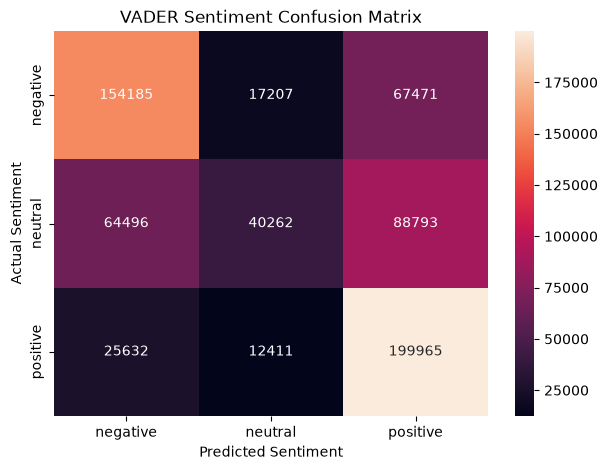

In [13]:
# STEP 12: CONFUSION MATRIX AND ACCURACY

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert labels to lowercase
actual = df["Label"].str.lower()
predicted = df["VADER_Sentiment"]

# Accuracy
accuracy = accuracy_score(actual, predicted)

print("===== VADER PERFORMANCE =====")
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(actual, predicted))

# Confusion Matrix
cm = confusion_matrix(
    actual,
    predicted,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("VADER Sentiment Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [14]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# STEP 13: FINAL PROJECT SUMMARY

print("==============================================")
print("     TWITTER SENTIMENT ANALYSIS - SUMMARY")
print("==============================================")

print(f"\nOriginal Dataset Rows: 691248")
print(f"Final Dataset Rows: {len(final_df)}")
print(f"Rows Removed: {691248 - len(final_df)}")

print(f"\nFinal Columns: {final_df.shape[1]}")

print("\nSentiment Distribution:")
print(final_df["Label"].value_counts())

print(f"\nVADER Accuracy: {accuracy * 100:.2f}%")

print("\nFinal File:")
print("Twitter_Sentiment_Analysis_Final.csv")

print("\nProject Status: COMPLETED")

     TWITTER SENTIMENT ANALYSIS - SUMMARY

Original Dataset Rows: 691248
Final Dataset Rows: 670422
Rows Removed: 20826

Final Columns: 5

Sentiment Distribution:
Label
negative    238863
positive    238008
neutral     193551
Name: count, dtype: int64

VADER Accuracy: 58.83%

Final File:
Twitter_Sentiment_Analysis_Final.csv

Project Status: COMPLETED
